In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

sys.path.append('../src')
from functions import load_dataset, create_stratified_split, separate_features_target, build_cpg_preprocessing_pipeline, bootstrap_evaluation, stability_selection

# Task 1

Development Set Dimensions: 456 rows (samples) x 1004 columns

Age Distribution
Mean:  64.45 years
Std:   14.63 years
Range: 19 to 101 years

Class Balance (Sex)
sex
M    232
F    224
Name: count, dtype: int64


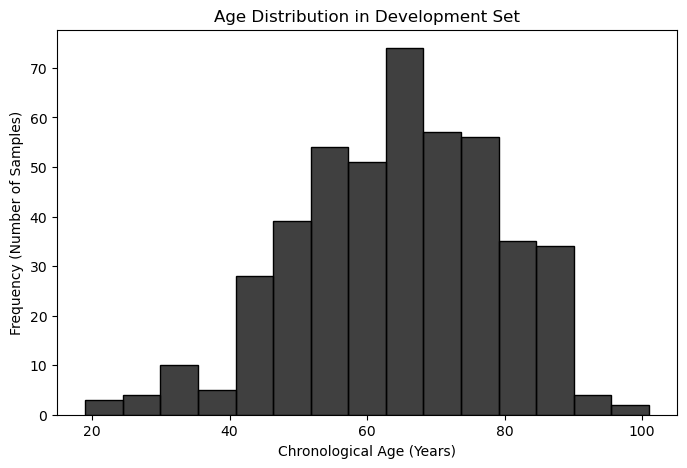

In [2]:
# Load Data
dev_filepath = '../data/development_data.csv'
eval_filepath = '../data/evaluation_data.csv'

dev_df = load_dataset(dev_filepath)
eval_df = load_dataset(eval_filepath)

# Development Set Dimensions
print(f"Development Set Dimensions: {dev_df.shape[0]} rows (samples) x {dev_df.shape[1]} columns")

# Age Distribution
age_mean = dev_df['age'].mean()
age_std = dev_df['age'].std()
age_min = dev_df['age'].min()
age_max = dev_df['age'].max()

print("\nAge Distribution")
print(f"Mean:  {age_mean:.2f} years")
print(f"Std:   {age_std:.2f} years")
print(f"Range: {age_min} to {age_max} years")

# Class Balance for Sex
print("\nClass Balance (Sex)")
print(dev_df['sex'].value_counts())

# Visualisation of Age Distribution
plt.figure(figsize=(8, 5))

sns.histplot(dev_df['age'], bins=15, color='black', edgecolor='black')
plt.title('Age Distribution in Development Set')
plt.xlabel('Chronological Age (Years)')
plt.ylabel('Frequency (Number of Samples)')
plt.show()

In [3]:
# Split development data into 80% Train / 20% Validation stratified by age
train_df, val_df = create_stratified_split(
    dev_df, 
    target_col='age', 
    test_size=0.2, 
    random_state=42,
    n_quantiles=10
)

# Verify the Split
print(f"Total Development Data: {dev_df.shape[0]} samples")
print(f"Training Set:           {train_df.shape[0]} samples")
print(f"Validation Set:         {val_df.shape[0]} samples")

Total Development Data: 456 samples
Training Set:           364 samples
Validation Set:         92 samples


In [4]:
# Check the number of missing values in the training set
missing_counts = train_df.isnull().sum()
total_missing = missing_counts.sum()
cols_with_missing = missing_counts[missing_counts > 0]

print(f"Total missing values in training set: {total_missing}")
print(f"Number of columns with missing values: {len(cols_with_missing)} out of {train_df.shape[1]}")

Total missing values in training set: 10992
Number of columns with missing values: 1000 out of 1004


Since the assignment specifies that the missing CpG beta values are Missing Completely at Random (MCAR) and because we have a relatively small sample size, we cannot simply drop rows because that will severely deplete the training dataset. Instead, a good idea might be to use median imputation. Below we instantiate a pipeline for feature imputation and scaling.


In [5]:
pipeline = build_cpg_preprocessing_pipeline()

Now we separate our features (CpG sites) from target (Age) and metadata (Sex/Ethnicity). We will treat CpG beta values as our only predictive features. We want the model to learn directly from the DNA. If we also include sex and ethnicity as features, the model might use demographics to adjust the age guess rather than relying purely on the biological aging signal.

Instead, we will keep sex and ethnicity in a metadata dataframe to evaluate the model later.

In [6]:
X_train, y_train, meta_train = separate_features_target(train_df)
X_val, y_val, meta_val = separate_features_target(val_df)

In [7]:
# Fit and Transform the training data
# Calculate the medians and scaling parameters and apply them
X_train_processed = pipeline.fit_transform(X_train)

# Transform the validation data
# Apply the exact medians and scales learned from the training data to the validation data
X_val_processed = pipeline.transform(X_val)

# Task 2

In [8]:

# Initialize the OLS Linear Regression model
ols_model = LinearRegression()

# Fit on the preprocessed training data
ols_model.fit(X_train_processed, y_train)

# Generate predictions on the validation set once
y_pred_val_ols = ols_model.predict(X_val_processed)

# Execute and Report Metrics
print("OLS Linear Regression Performance (Validation Set)")

# Run the function on the OLS validation predictions
ols_metrics = bootstrap_evaluation(y_val, y_pred_val_ols, n_bootstraps=1000, seed=42)

# Print the results
for metric, (mean_val, lower_ci, upper_ci) in ols_metrics.items():
    print(f"{metric:<10}: {mean_val:>8.3f} [{lower_ci:>8.3f}, {upper_ci:>8.3f}]")

OLS Linear Regression Performance (Validation Set)
RMSE      :    4.746 [   3.701,    5.918]
MAE       :    3.574 [   2.950,    4.269]
R²        :    0.892 [   0.823,    0.936]
Pearson r :    0.950 [   0.917,    0.971]


In [9]:
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR

# Define the models
models = {
    "ElasticNet": ElasticNet(),
    "SVR (RBF Kernel)": SVR(),
    "BayesianRidge": BayesianRidge()
}

# Dictionary to store the evaluation results for comparison later
validation_results = {}

print("Default Regularized Models Performance (Validation Set)")

# Train and Evaluate Each Model
for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Fit the model on the preprocessed training data
    model.fit(X_train_processed, y_train)
    
    # Generate predictions on the validation set
    y_pred_val = model.predict(X_val_processed)
    
    # Run bootstrap evaluation as before
    metrics = bootstrap_evaluation(y_val, y_pred_val, n_bootstraps=1000, seed=42)
    
    # Save metrics
    validation_results[model_name] = metrics
    
    # Print results
    print(f"Results for {model_name}:")
    for metric, (mean_val, lower_ci, upper_ci) in metrics.items():
         print(f"  {metric:<10}: {mean_val:>8.3f}  [{lower_ci:>8.3f}, {upper_ci:>8.3f}]")
    print("-" * 60)

Default Regularized Models Performance (Validation Set)
Training ElasticNet...
Results for ElasticNet:
  RMSE      :    4.512  [   3.742,    5.305]
  MAE       :    3.478  [   2.912,    4.083]
  R²        :    0.903  [   0.853,    0.938]
  Pearson r :    0.953  [   0.926,    0.971]
------------------------------------------------------------
Training SVR (RBF Kernel)...
Results for SVR (RBF Kernel):
  RMSE      :    9.301  [   7.391,   11.267]
  MAE       :    6.822  [   5.508,    8.249]
  R²        :    0.596  [   0.505,    0.675]
  Pearson r :    0.848  [   0.791,    0.896]
------------------------------------------------------------
Training BayesianRidge...
Results for BayesianRidge:
  RMSE      :    3.880  [   3.116,    4.754]
  MAE       :    2.909  [   2.410,    3.463]
  R²        :    0.928  [   0.885,    0.958]
  Pearson r :    0.965  [   0.942,    0.980]
------------------------------------------------------------


The Ordinary Least Squares (OLS) model served as our unregularized baseline floor.

ElasticNet: (Beats OLS)

ElasticNet successfully beat the baseline because it applies a combination of L1 (Lasso) and L2 (Ridge) penalties. The L1 penalty forces the coefficients of noisy or redundant CpG sites to exactly zero (performing intrinsic feature selection), while the L2 penalty prevents highly correlated biological markers from behaving erratically. This controlled the variance that plagued the OLS model.

BayesianRidge: (Beats OLS)

Bayesian Ridge proved to be the strongest performing model. Instead of computing fixed point estimates for coefficients like OLS, it assigns a probability distribution to each feature's weight. Furthermore, its Automatic Relevance Determination (ARD) internally optimized the regularization strength during training. This probabilistic approach is highly robust to the multicollinearity inherent in microarray data, allowing it to generalize significantly better than OLS.

Support Vector Regression (RBF Kernel): (Fails to Beat OLS)

SVR with an RBF kernel was the only model that failed to beat the unregularized baseline. While highly powerful, the RBF kernel relies on calculating distances between points in a transformed high-dimensional space. At scikit-learn's default hyperparameters, SVR suffers severely from the "curse of dimensionality" when exposed to 1,000 features. The default regularization parameter (C) and kernel width (γ) were unable to construct a generalizable decision tube, leading to massive errors on unseen validation data.

# Task 3

Running Stability Selection (50 iterations)...

Total stable features selected: 186


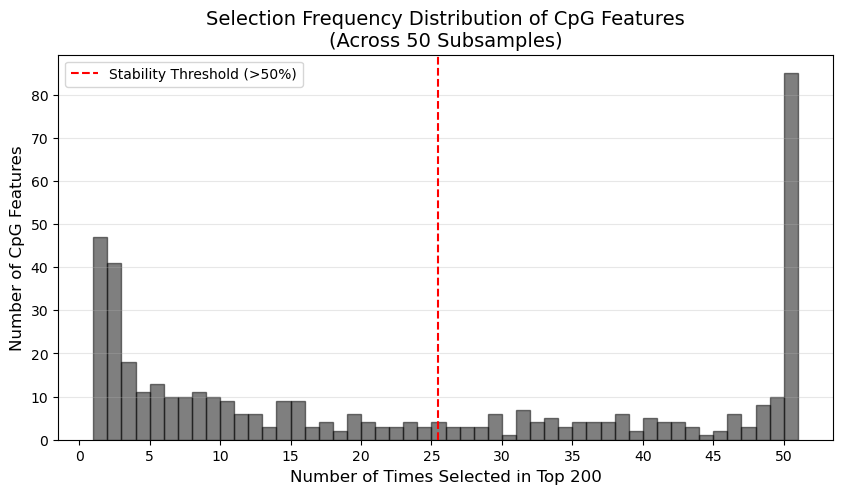


New X_train_stable shape: (364, 186)


In [10]:
# Execute Stability Selection
# X_train.columns contains our original 1000 CpG names before scaling stripped them
stable_cpgs, cpg_counts = stability_selection(
    X_train_processed, 
    y_train, 
    feature_names=X_train.columns, 
    n_iterations=50, 
    subsample_fraction=0.8, 
    top_k=200, 
    threshold=0.5, 
    seed=42
)

# Report Results and Visualize Distribution
print(f"\nTotal stable features selected: {len(stable_cpgs)}")

# Extract the frequencies for visualization
frequencies = list(cpg_counts.values())

plt.figure(figsize=(10, 5))
plt.hist(frequencies, bins=range(1, 52), color='black', edgecolor='black', alpha=0.5)
plt.axvline(x=25.5, color='red', linestyle='--', label='Stability Threshold (>50%)')

plt.title('Selection Frequency Distribution of CpG Features\n(Across 50 Subsamples)', fontsize=14)
plt.xlabel('Number of Times Selected in Top 200', fontsize=12)
plt.ylabel('Number of CpG Features', fontsize=12)
plt.xticks(range(0, 55, 5))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Create the subsetted training and validation matrices using the stable features
# We find the column indices of the stable features to slice our numpy arrays
stable_indices = [X_train.columns.get_loc(cpg) for cpg in stable_cpgs]

X_train_stable = X_train_processed[:, stable_indices]
X_val_stable = X_val_processed[:, stable_indices]

print(f"\nNew X_train_stable shape: {X_train_stable.shape}")

Because the vast majority of the selected features sit far to the right of the red threshold line (at a perfect 50), this X_train_stable subset is incredibly robust. A model trained on this data is highly unlikely to overfit to the quirks of specific patients, as these markers are universally correlated with age across the entire dataset.

mRMR Feature Selection


100%|██████████| 200/200 [00:12<00:00, 16.60it/s]


Top 10 selected features by mRMR and their relevance scores:
1. cg16867657 (Relevance: 813.4785)
2. cg06639320 (Relevance: 482.4772)
3. cg10501210 (Relevance: 438.3722)
4. cg22454769 (Relevance: 486.3208)
5. cg24724428 (Relevance: 410.3838)
6. cg21572722 (Relevance: 379.8864)
7. cg22796704 (Relevance: 302.7579)
8. cg24079702 (Relevance: 367.6800)
9. cg01974375 (Relevance: 303.0589)
10. cg06784991 (Relevance: 292.7919)

Visualising Overlap


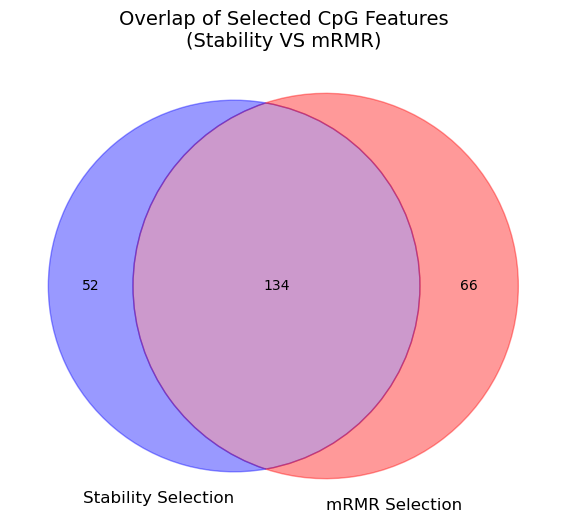

Number of overlapping features: 134

Evaluating Feature Sets (Proxy: ElasticNet)
Validation RMSE (Stability Selection): 5.261 years
Validation RMSE (mRMR Selection):      4.643 years
--------------------------------------------------
CONCLUSION: mRMR performed better by 0.619 years.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mrmr import mrmr_regression
from matplotlib_venn import venn2
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error

print("mRMR Feature Selection")

X_train_df = pd.DataFrame(X_train_processed, columns=X_train.columns)
y_train_series = pd.Series(y_train.values)

# Set K to 200 to match the scale of our Stability Selection
K_mrmr = 200

# Run mRMR
selected_features_mrmr, relevance, redundancy = mrmr_regression(
    X=X_train_df, 
    y=y_train_series, 
    K=K_mrmr, 
    return_scores=True
)

# Extract top 10 features and their relevance scores
top_10_mrmr = selected_features_mrmr[:10]
print("\nTop 10 selected features by mRMR and their relevance scores:")
for i, feature in enumerate(top_10_mrmr):
    score = relevance.loc[feature]
    print(f"{i+1}. {feature} (Relevance: {score:.4f})")

# Create the subsetted feature matrices for mRMR
mrmr_indices = [X_train.columns.get_loc(cpg) for cpg in selected_features_mrmr]
X_train_mrmr = X_train_processed[:, mrmr_indices]
X_val_mrmr = X_val_processed[:, mrmr_indices]

# Visualise Feature Overlap
print("\nVisualising Overlap")

set_stable = set(stable_cpgs)
set_mrmr = set(selected_features_mrmr)

plt.figure(figsize=(8, 6))
venn = venn2([set_stable, set_mrmr], ('Stability Selection', 'mRMR Selection'))
plt.title("Overlap of Selected CpG Features\n(Stability VS mRMR)", fontsize=14)
# Adjust colors for aesthetics
if venn.get_patch_by_id('10'): venn.get_patch_by_id('10').set_color('blue')
if venn.get_patch_by_id('01'): venn.get_patch_by_id('01').set_color('red')
if venn.get_patch_by_id('11'): venn.get_patch_by_id('11').set_color('purple')
plt.show()

overlap_count = len(set_stable.intersection(set_mrmr))
print(f"Number of overlapping features: {overlap_count}")


# Method Comparison via Proxy Model
print("\nEvaluating Feature Sets (Proxy: ElasticNet)")

# Initialize the proxy models (using default hyperparameters)
proxy_stable = ElasticNet(random_state=42)
proxy_mrmr = ElasticNet(random_state=42)

# Train and predict using the Stability Selection subset
proxy_stable.fit(X_train_stable, y_train)
y_pred_stable = proxy_stable.predict(X_val_stable)
rmse_stable = np.sqrt(mean_squared_error(y_val, y_pred_stable))

# Train and predict using the mRMR subset
proxy_mrmr.fit(X_train_mrmr, y_train)
y_pred_mrmr = proxy_mrmr.predict(X_val_mrmr)
rmse_mrmr = np.sqrt(mean_squared_error(y_val, y_pred_mrmr))

# Report Comparison
print(f"Validation RMSE (Stability Selection): {rmse_stable:.3f} years")
print(f"Validation RMSE (mRMR Selection):      {rmse_mrmr:.3f} years")

print("-" * 50)
if rmse_mrmr < rmse_stable:
    print(f"CONCLUSION: mRMR performed better by {(rmse_stable - rmse_mrmr):.3f} years.")
    X_train_final = X_train_mrmr
    X_val_final = X_val_mrmr
    final_features = selected_features_mrmr
elif rmse_stable < rmse_mrmr:
    print(f"CONCLUSION: Stability Selection performed better by {(rmse_mrmr - rmse_stable):.3f} years.")
    X_train_final = X_train_stable
    X_val_final = X_val_stable
    final_features = stable_cpgs
else:
    print("CONCLUSION: Both methods resulted in the exact same Validation RMSE.")

Because the assignment parameters for Stability Selection explicitly defined extracting the top 200 features per subsample, K=200 was used for the mRMR algorithm. By holding the dimensionality constant across both methods, any difference in proxy model performance on the validation set could be attributed to the quality and informational diversity of the selected features (e.g., mRMR's redundancy penalty), rather than a discrepancy in the quantity of features.

# Task 4

In [12]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR

print("Preparing Full Development Set for CV")
# Recombine the training and validation sets 
X_dev_final = np.vstack((X_train_final, X_val_final))
y_dev = np.concatenate((y_train, y_val))

# Define the Models and their Search Spaces
param_grids = {
    "ElasticNet": {
        "model": ElasticNet(random_state=42, max_iter=10000),
        "params": {
            "alpha": loguniform(0.001, 10),
            "l1_ratio": uniform(0.1, 0.9) 
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "C": loguniform(0.1, 500),
            "epsilon": [0.01, 0.1, 0.5, 1.0],
            "kernel": ['rbf', 'linear']
        }
    },
    "BayesianRidge": {
        "model": BayesianRidge(),
        "params": {
            "alpha_1": loguniform(1e-7, 1e-3),
            "alpha_2": loguniform(1e-7, 1e-3),
            "lambda_1": loguniform(1e-7, 1e-3),
            "lambda_2": loguniform(1e-7, 1e-3)
        }
    }
}

# Execute RandomizedSearchCV
best_models = {}
tuned_results = {}

print("\nStarting Hyperparameter Tuning (40 iterations per model)")

for name, config in param_grids.items():
    print(f"\nTuning {name}...")
    
    # Initialize the search
    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=40,                            # 40 random trials
        scoring='neg_root_mean_squared_error',# Minimize Mean CV RMSE
        cv=5,                                 # 5-fold cross-validation
        random_state=42,                      # Seed = 42
        refit=True,                           # Automatically refits best params on the full X_dev_final!
        n_jobs=-1                             # Uses all CPU cores to speed up the process
    )
    
    # Fit the search on the full development set
    search.fit(X_dev_final, y_dev)
    
    # Save the best fitted model and the raw search object
    best_models[name] = search.best_estimator_
    tuned_results[name] = search
    
    # Extract and format the best RMSE (sklearn returns negative RMSE, so we multiply by -1)
    best_cv_rmse = -search.best_score_
    
    print(f"Best CV RMSE:    {best_cv_rmse:.3f} years")
    print(f"Best Parameters: {search.best_params_}")

print("\nTuning Complete")
print("All best models have been automatically refitted on the full 456-sample dataset.")

Preparing Full Development Set for CV
Full Development Set Shape: (456, 200) (Expected: 456 rows)

Starting Hyperparameter Tuning (40 iterations per model)

Tuning ElasticNet...
Best CV RMSE:    4.831 years
Best Parameters: {'alpha': 0.23423849847112907, 'l1_ratio': 0.14180537144799796}

Tuning SVR...
Best CV RMSE:    5.243 years
Best Parameters: {'C': 41.175995922628786, 'epsilon': 0.5, 'kernel': 'rbf'}

Tuning BayesianRidge...
Best CV RMSE:    4.829 years
Best Parameters: {'alpha_1': 3.798214508453255e-07, 'alpha_2': 9.074256288983855e-06, 'lambda_1': 0.0008761971101023686, 'lambda_2': 9.294394155644988e-07}

Tuning Complete
All best models have been automatically refitted on the full 456-sample dataset.
